# Basic NLP with `text_records()`

This notebook shows a simple handoff from `crategraph` to an NLP library.

The point of using `crategraph` here is that we do not read every file directly. We use the RO-Crate graph to select file entities, keep provenance with `text_records()`, then group the NLP results by genre metadata recorded in the graph.

## Install TextBlob

Run this cell once if TextBlob is not already available in your notebook environment.

In [19]:
!uv pip install textblob

Audited 1 package in 7ms


In [20]:
import re
from collections import Counter
from pathlib import Path

import pandas as pd
from textblob import TextBlob

from crategraph import Crate

## Load the crate

This helper finds the repository root from the notebook's current working directory, then loads the Australian Corpus of English crate from `data/`.

In [21]:
def find_repo_root(start=None):
    if start is None:
        start = Path.cwd()
    for path in (start, *start.parents):
        crate_metadata = path / "data/ldaca/Australian_Corpus_of_English/ro-crate-metadata.json"
        if crate_metadata.exists():
            return path
    raise FileNotFoundError("Could not find data/ldaca/Australian_Corpus_of_English")


repo_root = find_repo_root()
crate = Crate(repo_root / "data/ldaca/Australian_Corpus_of_English")
crate.summary()

=== Graph Summary ===
Source: /Users/drrusso/Documents/Repos/cdl2-rocrates/data/ldaca/Australian_Corpus_of_English
Entities: 2582 | Relationships: 11952

Entity types:
  File              1717  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  RepositoryObject   850  ▒▒▒▒▒▒▒
  DefinedTerm          5  
  CreativeWork         1  
  Organization         1  
  +8 more

Relationship types:
  license                 2568  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  ldac:communicationMode  2567  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  hasPart                 2550  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
  ldac:linguisticGenre    1714  ▒▒▒▒▒▒▒▒▒▒
  ldac:indexableText       850  ▒▒▒▒▒
  +5 more

Most connected: Attribution 4.0 International (CC BY 4.0) (2568), WrittenLanguage (2567), Report (1173)

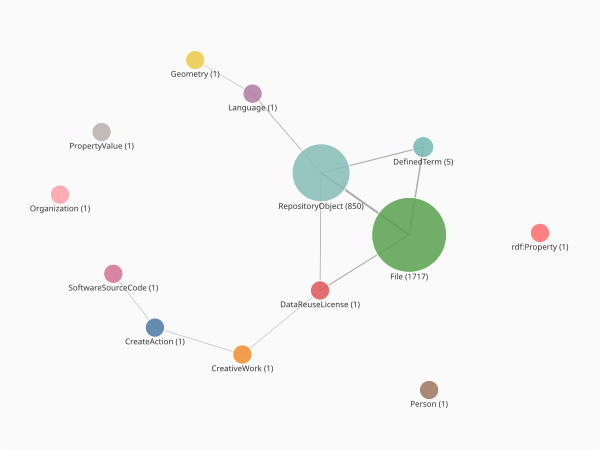

In [22]:
crate.glimpse()

## Select files to analyse

`text_records()` extracts text from file entities. We still make the file selection explicit so the notebook demonstrates the graph-to-NLP handoff on a filtered graph.

In [23]:
text_files = crate.select(entity_types=["File"])

text_files.summary()

=== Graph Summary ===
Source: /Users/drrusso/Documents/Repos/cdl2-rocrates/data/ldaca/Australian_Corpus_of_English
Entities: 1717 | Relationships: 0

Entity types:
  File  1717  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒

Most connected: G70b#Raw (0), E17b#Text (0), H16#Raw (0)

Build a small lookup table from the graph: file ID, title, and genre. The genre relationship is specific to this crate, but the pattern is general: use graph metadata to make NLP groupings meaningful.

In [24]:
file_ids = {entity.id for entity in text_files.entities}

file_genres = pd.DataFrame(
    {
        "entity_id": rel.source,
        "title": crate.get(rel.source).name,
        "genre": crate.get(rel.target).name,
    }
    for rel in crate.relationships
    if rel.type == "ldac:linguisticGenre" and rel.source in file_ids
).sort_values(["genre", "entity_id"])

Counter(file_genres["genre"])

Counter({'Report': 592, 'Informational': 189, 'Narrative': 65, 'Ludic': 18})

## Hand the text to NLP tools

`text_records()` returns one row-like record per text unit, with provenance columns kept alongside the text.

For a quick demo, take 15 files per genre.

In [ ]:
selected = file_genres.groupby("genre", group_keys=False).head(15)

records = pd.DataFrame(
    text_files.text_records(filters={"entity_id": selected["entity_id"].tolist()})
).merge(selected, on="entity_id", how="left")

records[["entity_id", "genre", "title", "text"]].head()

In [ ]:
word_pattern = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")


def word_count(text):
    return len(word_pattern.findall(text))


records["word_count"] = records["text"].map(word_count)
records["polarity"] = records["text"].map(lambda text: TextBlob(text).sentiment.polarity)

records[["entity_id", "genre", "word_count", "polarity", "title"]].head()

## Summarise by graph-derived genre

The grouping column comes from RO-Crate relationships, not from file names.

In [ ]:
records.groupby("genre").agg(
    documents=("entity_id", "count"),
    mean_words=("word_count", "mean"),
    mean_polarity=("polarity", "mean"),
).sort_values("documents", ascending=False)